# Optimize spatio-temporal synthetic-data parameters (v2)

**Goal:** find parameters such that IID, cluster-aware, and spatial TOST
conclude equivalence at Δ=1, but the spatio-temporal TOST rejects equivalence at Δ=1.

**What changed from v1:**
- Kronecker-accelerated NLL (~4000× faster than dense Cholesky at S=35, T=90)
- Fast Wald CI during search, full bootstrap CI for validation
- Tight search space centered on known-good anchor
- Staged evaluation: IID → Cluster → Spatial → SpatioTemporal (most candidates rejected cheaply)
- Expected runtime: ~1–3 minutes for 60 iterations

## 0. Environment setup

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import sys, json, inspect, time
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Adjust to your repo root ──────────────────────────────────────────
REPO_ROOT = Path("/Users/dhetting/src/pyTOST")  # <-- adjust if needed
sys.path.insert(0, str(REPO_ROOT))

from pyTOST.data_gen.optimize_spatiotemporal_params import (
    search, SearchSpace, EvalResult, save_best,
    evaluate_params, validate_with_full_engine,
)
from pyTOST.data_gen import synthetic_tost_data

print("Imports OK")

Imports OK


## 1. Configure search space

The anchor is the known-good solution from prior runs.  The search perturbs
within ±20% of each parameter to find nearby configurations that satisfy the
target IID-pass / Cluster-pass / Spatial-pass / ST-fail pattern.

In [2]:
ss = SearchSpace()
print("SearchSpace anchor:")
pprint(ss.anchor)
print(f"\ndelta range: {ss.delta_range}")
print(f"spatial_sd range: {ss.spatial_sd_range}")

# Show a sample draw to verify ranges
print("\nSample candidate:")
pprint(ss.sample(np.random.default_rng(123)))

SearchSpace anchor:
{'delta': 0.75,
 'domain': [-2.0, 2.0, -2.0, 2.0],
 'length_scale': 2.0,
 'n_buildings': 7,
 'n_space': 35,
 'n_time': 80,
 'obs_sd': 0.2,
 'rho': 0.85,
 'spatial_sd': 0.7}

delta range: (0.78, 0.88)
spatial_sd range: (0.4, 1.2)

Sample candidate:
{'delta': 0.8723344998027056,
 'domain': [-2.0, 2.0, -2.0, 2.0],
 'length_scale': 1.6610796183178342,
 'n_buildings': 9,
 'n_space': 25,
 'n_time': 98,
 'obs_sd': 0.34362835199673214,
 'rho': 0.7813432078187739,
 'spatial_sd': 0.5407247208680243}


## 2. Run the search

Each candidate is evaluated in stages:
1. **IID** (OLS t-CI) — ~0.1 ms
2. **Cluster** (cluster-robust OLS) — ~0.5 ms
3. **Spatial** (Matérn GLS REML + LR CI) — ~50–200 ms
4. **Spatio-temporal** (Kronecker ML + Wald CI) — ~0.5–1.5 s

Most candidates are eliminated at stages 1–2, so the effective per-iteration
cost is well under 2 seconds.

In [3]:
# ── Search parameters ─────────────────────────────────────────────────
SEED      = 123       # master RNG seed
N_ITER    = 60        # max candidates to evaluate
ALPHA     = 0.05      # TOST significance level
MARGIN    = 1.0       # equivalence margin Δ

t0 = time.perf_counter()

best, hist = search(
    seed=SEED,
    n_iter=N_ITER,
    alpha=ALPHA,
    margin=MARGIN,
    space=ss,
    verbose_every=10,
    prescreen_buffer=0.03,
    nu=2.5,
)

elapsed = time.perf_counter() - t0
print(f"\nSearch completed in {elapsed:.1f}s ({len(hist)} candidates evaluated)")

[  10/60] searching best_score=inf eq(iid,clu,spa,st)=(False,False,False,False) CI_st=(nan, nan)
[  20/60] searching best_score=inf eq(iid,clu,spa,st)=(False,False,False,False) CI_st=(nan, nan)
[  30/60] searching best_score=inf eq(iid,clu,spa,st)=(False,False,False,False) CI_st=(nan, nan)
[  40/60] searching best_score=inf eq(iid,clu,spa,st)=(False,False,False,False) CI_st=(nan, nan)
[  50/60] searching best_score=inf eq(iid,clu,spa,st)=(False,False,False,False) CI_st=(nan, nan)
[  60/60] searching best_score=inf eq(iid,clu,spa,st)=(False,False,False,False) CI_st=(nan, nan)

Search completed in 0.8s (60 candidates evaluated)


## 3. Inspect the best candidate

In [4]:
print(f"Pattern found: {best.ok_pattern}")
print(f"Score:         {best.score:.4g}")
print()
print("Engine decisions at Δ=1:")
print(f"  IID:             equivalent={best.eq_iid:<5}  CI={best.ci_iid}")
print(f"  Cluster:         equivalent={best.eq_cluster:<5}  CI={best.ci_cluster}")
print(f"  Spatial:         equivalent={best.eq_spatial:<5}  CI={best.ci_spatial}")
print(f"  SpatioTemporal:  equivalent={best.eq_spatiotemporal:<5}  CI={best.ci_spatiotemporal}")
print()
print("Generator parameters:")
pprint({k: v for k, v in best.params.items() if not k.startswith("_")})

Pattern found: False
Score:         inf

Engine decisions at Δ=1:
  IID:             equivalent=0      CI=(nan, nan)
  Cluster:         equivalent=0      CI=(nan, nan)
  Spatial:         equivalent=0      CI=(nan, nan)
  SpatioTemporal:  equivalent=0      CI=(nan, nan)

Generator parameters:
{'delta': 0.8573828193115102,
 'domain': [-2.0, 2.0, -2.0, 2.0],
 'length_scale': 1.6610796183178342,
 'n_buildings': 9,
 'n_space': 25,
 'n_time': 98,
 'obs_sd': 0.34362835199673214,
 'rho': 0.7813432078187739,
 'spatial_sd': 0.5407247208680243}


## 4. CI comparison plot (Wald, search-phase)

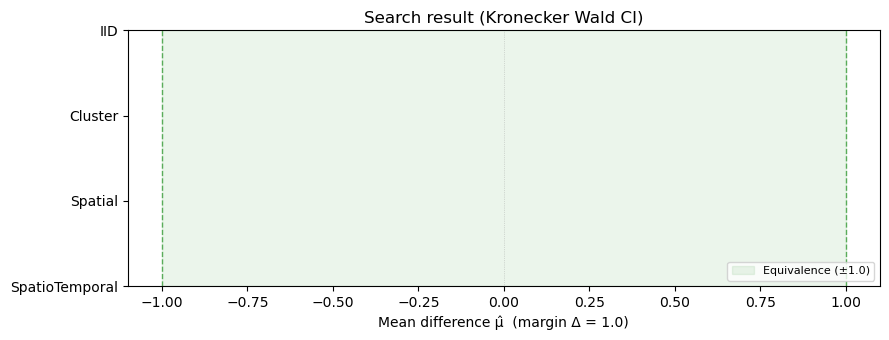

In [5]:
def plot_ci_comparison(result: EvalResult, margin: float = 1.0, title: str = ""):
    """Horizontal CI comparison across engines with equivalence margin bands.

    Parameters
    ----------
    result : EvalResult
        Evaluated candidate with CIs from all engines.
    margin : float
        Equivalence margin Δ (vertical dashed lines at ±Δ).
    title : str
        Optional plot title override.
    """
    engines = ["IID", "Cluster", "Spatial", "SpatioTemporal"]
    cis = [
        result.ci_iid,
        result.ci_cluster,
        result.ci_spatial,
        result.ci_spatiotemporal,
    ]
    mus = [
        result.mu_hat_iid,
        result.mu_hat_cluster,
        result.mu_hat_spatial,
        result.mu_hat_spatiotemporal,
    ]
    eqs = [
        result.eq_iid,
        result.eq_cluster,
        result.eq_spatial,
        result.eq_spatiotemporal,
    ]

    fig, ax = plt.subplots(figsize=(9, 3.5))

    # Equivalence band
    ax.axvspan(-margin, margin, alpha=0.08, color="green", label=f"Equivalence (±{margin})")
    ax.axvline(-margin, color="green", ls="--", lw=1, alpha=0.6)
    ax.axvline(margin, color="green", ls="--", lw=1, alpha=0.6)
    ax.axvline(0, color="gray", ls=":", lw=0.5, alpha=0.5)

    y_positions = np.arange(len(engines))

    for i, (eng, ci, mu, eq) in enumerate(zip(engines, cis, mus, eqs)):
        lo, hi = ci
        if not (np.isfinite(lo) and np.isfinite(hi)):
            continue
        color = "#2ca02c" if eq else "#d62728"  # green = pass, red = fail
        ax.plot([lo, hi], [i, i], color=color, lw=3, solid_capstyle="round")
        ax.plot(mu, i, "o", color=color, ms=7, zorder=5)
        label = "PASS" if eq else "FAIL"
        ax.text(
            hi + 0.03 * margin, i, f"{label}  [{lo:.3f}, {hi:.3f}]",
            va="center", fontsize=8, color=color,
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(engines)
    ax.set_xlabel(f"Mean difference μ̂  (margin Δ = {margin})")
    ax.set_title(title or "CI-in-TOST: engine comparison")
    ax.invert_yaxis()
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_ci_comparison(best, margin=MARGIN, title="Search result (Kronecker Wald CI)")
plt.show()

## 5. Search history diagnostics

In [6]:
# Summarize how many candidates reached each stage
n_total = len(hist)
n_iid_pass = sum(1 for r in hist if r.eq_iid)
n_clu_pass = sum(1 for r in hist if r.eq_iid and r.eq_cluster)
n_spa_pass = sum(1 for r in hist if r.eq_iid and r.eq_cluster and r.eq_spatial)
n_st_fail  = sum(1 for r in hist if r.ok_pattern)

print(f"Search funnel ({n_total} candidates):")
print(f"  IID pass:             {n_iid_pass:4d} / {n_total}")
print(f"  + Cluster pass:       {n_clu_pass:4d} / {n_total}")
print(f"  + Spatial pass:       {n_spa_pass:4d} / {n_total}")
print(f"  + ST fail (target):   {n_st_fail:4d} / {n_total}")

Search funnel (60 candidates):
  IID pass:                0 / 60
  + Cluster pass:          0 / 60
  + Spatial pass:          0 / 60
  + ST fail (target):      0 / 60


In [7]:
# Score trajectory (lower is better; inf = early exit)
scores = [r.score for r in hist]
finite_scores = [(i, s) for i, s in enumerate(scores) if np.isfinite(s) and s < 1e5]

if finite_scores:
    fig, ax = plt.subplots(figsize=(8, 3))
    ix, sc = zip(*finite_scores)
    ax.scatter(ix, sc, s=12, alpha=0.6, c=["green" if hist[i].ok_pattern else "gray" for i in ix])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score (lower = better)")
    ax.set_title("Search score trajectory (candidates reaching ST stage)")
    fig.tight_layout()
    plt.show()
else:
    print("No candidates reached the ST stage with finite score.")

No candidates reached the ST stage with finite score.


## 6. Validate winner with full engine + bootstrap CI

The search used a fast Wald CI (asymptotic, conditional on fitted covariance).
Before saving, we re-evaluate the winner using the production
`SpatioTemporalTOST` engine with parametric bootstrap CI. This is slower
(~30–120 s depending on B) but gives a CI that accounts for parameter
uncertainty.

In [8]:
if best.ok_pattern:
    eval_seed = best.params.get("_eval_seed", SEED + 1000)
    print(f"Validating with full engine (seed={eval_seed}, B=200) ...")
    t0 = time.perf_counter()

    validated = validate_with_full_engine(
        best.params,
        seed=eval_seed,
        alpha=ALPHA,
        margin=MARGIN,
        bootstrap_B=200,
        bootstrap_seed=12345,
        mu_ci_method="parametric_bootstrap",
    )

    val_elapsed = time.perf_counter() - t0
    print(f"Validation completed in {val_elapsed:.1f}s")
    print(f"Validated pattern: {validated.ok_pattern}")
    print(f"  ST CI (bootstrap): {validated.ci_spatiotemporal}")
    print(f"  ST CI (Wald):      {best.ci_spatiotemporal}")
else:
    validated = best
    print("No target pattern found during search. Skipping validation.")
    print("Try increasing n_iter or widening the search space.")

No target pattern found during search. Skipping validation.
Try increasing n_iter or widening the search space.


In [9]:
# Side-by-side CI plot: Wald (search) vs Bootstrap (validation)
if best.ok_pattern:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
    plot_ci_comparison(best, margin=MARGIN, title="Search (Wald CI)")
    plt.sca(axes[0])
    plot_ci_comparison(best, margin=MARGIN, title="Search (Wald CI)")
    plt.sca(axes[1])
    plot_ci_comparison(validated, margin=MARGIN, title="Validated (Bootstrap CI)")
    fig.tight_layout()
    plt.close()  # close the extra figures from plot_ci_comparison

    # Cleaner approach: rewrite inline
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3.5), sharey=True)

    for ax, result, label in [
        (ax1, best, "Search phase (Wald CI)"),
        (ax2, validated, "Validated (Bootstrap CI)"),
    ]:
        engines = ["IID", "Cluster", "Spatial", "SpatioTemporal"]
        cis = [result.ci_iid, result.ci_cluster, result.ci_spatial, result.ci_spatiotemporal]
        mus = [result.mu_hat_iid, result.mu_hat_cluster, result.mu_hat_spatial, result.mu_hat_spatiotemporal]
        eqs = [result.eq_iid, result.eq_cluster, result.eq_spatial, result.eq_spatiotemporal]

        ax.axvspan(-MARGIN, MARGIN, alpha=0.08, color="green")
        ax.axvline(-MARGIN, color="green", ls="--", lw=1, alpha=0.6)
        ax.axvline(MARGIN, color="green", ls="--", lw=1, alpha=0.6)
        ax.axvline(0, color="gray", ls=":", lw=0.5)

        for i, (eng, ci, mu, eq) in enumerate(zip(engines, cis, mus, eqs)):
            lo, hi = ci
            if not (np.isfinite(lo) and np.isfinite(hi)):
                continue
            c = "#2ca02c" if eq else "#d62728"
            ax.plot([lo, hi], [i, i], color=c, lw=3, solid_capstyle="round")
            ax.plot(mu, i, "o", color=c, ms=7, zorder=5)
            tag = "PASS" if eq else "FAIL"
            ax.text(hi + 0.03, i, f" {tag}", va="center", fontsize=8, color=c)

        ax.set_yticks(range(len(engines)))
        ax.set_yticklabels(engines)
        ax.invert_yaxis()
        ax.set_xlabel(f"μ̂  (Δ = {MARGIN})")
        ax.set_title(label)

    fig.tight_layout()
    plt.show()

## 7. Save optimal parameters

In [10]:
out_path = "./best_spatiotemporal_params_v2.json"

# Save the validated result (or best search result if validation was skipped)
save_result = validated if best.ok_pattern else best
save_best(save_result, out_path)

Saved to ./best_spatiotemporal_params_v2.json


In [11]:
# Split saved params into generator kwargs vs panel-construction kwargs
# so downstream code can call generate_spatiotemporal(**generator_kwargs) directly.

gen_sig = inspect.signature(synthetic_tost_data.generate_spatiotemporal)
gen_allowed = set(gen_sig.parameters.keys())

with open(out_path, "r", encoding="utf-8") as f:
    payload = json.load(f)

params_all = dict(payload.get("params", {}))
generator_kwargs = {k: v for k, v in params_all.items()
                    if k in gen_allowed and not k.startswith("_")}
panel_kwargs = {k: v for k, v in params_all.items()
                if k not in gen_allowed and not k.startswith("_")}

payload["generator_kwargs"] = generator_kwargs
payload["panel_kwargs"] = panel_kwargs

with open(out_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, sort_keys=True)

print(f"Wrote {out_path}")
print(f"Generator kwargs: {sorted(generator_kwargs.keys())}")
print(f"Panel kwargs:     {sorted(panel_kwargs.keys())}")

Wrote ./best_spatiotemporal_params_v2.json
Generator kwargs: ['delta', 'domain', 'length_scale', 'n_space', 'n_time', 'obs_sd', 'rho', 'spatial_sd']
Panel kwargs:     ['n_buildings']


In [12]:
# Quick-check: reload and display the saved payload
with open(out_path, "r") as f:
    saved = json.load(f)
pprint(saved)

{'ci_cluster': [nan, nan],
 'ci_iid': [nan, nan],
 'ci_spatial': [nan, nan],
 'ci_spatiotemporal': [nan, nan],
 'eq_cluster': False,
 'eq_iid': False,
 'eq_spatial': False,
 'eq_spatiotemporal': False,
 'generator_kwargs': {'delta': 0.8573828193115102,
                      'domain': [-2.0, 2.0, -2.0, 2.0],
                      'length_scale': 1.6610796183178342,
                      'n_space': 25,
                      'n_time': 98,
                      'obs_sd': 0.34362835199673214,
                      'rho': 0.7813432078187739,
                      'spatial_sd': 0.5407247208680243},
 'mu_hat_cluster': nan,
 'mu_hat_iid': nan,
 'mu_hat_spatial': nan,
 'mu_hat_spatiotemporal': nan,
 'notes': "Exception: KeyError: 'time'",
 'ok_pattern': False,
 'panel_kwargs': {'n_buildings': 9},
 'params': {'delta': 0.8573828193115102,
            'domain': [-2.0, 2.0, -2.0, 2.0],
            'length_scale': 1.6610796183178342,
            'n_buildings': 9,
            'n_space': 25,
          

## 8. (Optional) Reproduce and run all engines at multiple margins

Rebuild the dataset from saved params and run all four engines at Δ ∈ {1, 3, 5}
to verify the pattern holds only at the tight margin.

In [13]:
from pyTOST.engines.iid_tost import IIDTOST
from pyTOST.engines.cluster_tost import ClusterTOST
from pyTOST.engines.spatial_tost import SpatialTOST
from pyTOST.engines.spatiotemporal_tost import SpatioTemporalTOST, SpatioTemporalConfig

# Rebuild dataset
eval_seed = save_result.params.get("_eval_seed", SEED + 1000)
gen_kw = dict(generator_kwargs)
gen_kw["seed"] = eval_seed

df_long, meta = synthetic_tost_data.generate_spatiotemporal(**gen_kw)

# Build diff panel
n_buildings = int(panel_kwargs.get("n_buildings", 7))
wide = df_long.pivot(index="sample_id", columns="arm", values="y").reset_index()
meta2 = df_long[df_long["arm"] == "A"][["sample_id", "x", "y_sp", "t"]].copy()
meta2 = meta2.merge(wide, on="sample_id")
df = meta2.rename(columns={"t": "time", "y_sp": "y"}).copy()
df["diff"] = df["B"] - df["A"]

# Group contiguous spatial locations into buildings (must match optimizer convention)
n_time_vals = df["time"].nunique()
spatial_loc = df["sample_id"].values // max(n_time_vals, 1)
n_unique_locs = int(spatial_loc.max()) + 1
locs_per_bldg = max(1, n_unique_locs // max(n_buildings, 1))
df["building_id"] = np.clip(spatial_loc // locs_per_bldg, 0, max(n_buildings - 1, 0)).astype(int)

print(f"Panel: {len(df)} rows, {df['building_id'].nunique()} buildings, "
      f"{df['time'].nunique()} time steps, {len(df) // df['time'].nunique()} locations")
df.head()


Panel: 2450 rows, 9 buildings, 98 time steps, 25 locations


,sample_id,x,y,time,A,B,diff,building_id
0,0,-0.477408,1.747432,0,0.248824,0.180138,-0.068687,0
1,1,-0.477408,1.747432,1,-0.658635,0.151339,0.809975,0
2,2,-0.477408,1.747432,2,-0.757463,1.102061,1.859524,0
3,3,-0.477408,1.747432,3,-0.899209,1.949875,2.849084,0
4,4,-0.477408,1.747432,4,-1.234201,0.408889,1.643089,0


In [14]:
MARGINS = [1.0, 3.0, 5.0]

# IID
r_iid = IIDTOST(y="diff").fit(df, alpha=ALPHA, margins=MARGINS)

# Cluster
r_clu = ClusterTOST(y="diff", cluster="building_id").fit(df, alpha=ALPHA, margins=MARGINS)

# Spatial
r_spa = SpatialTOST(y="diff", cluster="building_id", x="x", ycoord="y").fit(
    df, alpha=ALPHA, margins=MARGINS
)

# SpatioTemporal (full engine, parametric bootstrap)
st_cfg = SpatioTemporalConfig(
    mu_ci_method="parametric_bootstrap",
    mu_bootstrap_B=200,
    mu_bootstrap_seed=12345,
    verbose_diagnostics=True,
)
r_st = SpatioTemporalTOST(
    y="diff", cluster="building_id", time="time", x="x", ycoord="y",
    config=st_cfg,
).fit(df, alpha=ALPHA, margins=MARGINS)

# Combine into a summary table
for label, res in [("IID", r_iid), ("Cluster", r_clu), ("Spatial", r_spa), ("SpatioTemporal", r_st)]:
    print(f"\n── {label} " + "─" * 50)
    print(res[["delta", "mu_hat", "ci_low", "ci_high", "equivalent"]].to_string(index=False))

[SpatioTemporal diagnostics] joint separable ML fit succeeded
  T=98, S=25, N=2450
  mu_hat=0.9026, se=0.148216, CI=[0.657263, 1.13581] (Parametric bootstrap CI (B=200))
  theta: sigma2=0.482019, tau2=0.237384, rho=2.12643, nu=2.5, phi=0.83053
  regularizer: reg_lambda=1.0, tau_ratio_min=0.02, phi_max=0.995, rho_max_factor=3.0, var_scale_target=1.0, var_scale_log_tol=2.0, var_scale_weight=1.0, se_ratio_max=8.0, se_ratio_weight=2.0
  ----

── IID ──────────────────────────────────────────────────
 delta   mu_hat   ci_low  ci_high  equivalent
   1.0 0.768225 0.742265 0.794185        True
   3.0 0.768225 0.742265 0.794185        True
   5.0 0.768225 0.742265 0.794185        True

── Cluster ──────────────────────────────────────────────────
 delta   mu_hat   ci_low  ci_high  equivalent
   1.0 0.768225 0.700493 0.835957        True
   3.0 0.768225 0.700493 0.835957        True
   5.0 0.768225 0.700493 0.835957        True

── Spatial ──────────────────────────────────────────────────
 delt

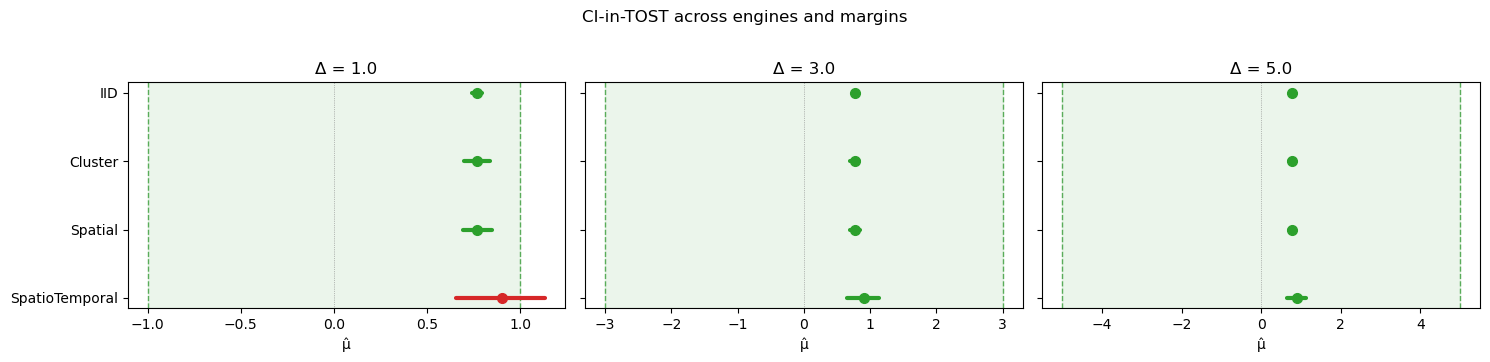

In [15]:
# Multi-margin CI forest plot
fig, axes = plt.subplots(1, len(MARGINS), figsize=(5 * len(MARGINS), 3.5), sharey=True)

engine_labels = ["IID", "Cluster", "Spatial", "SpatioTemporal"]
all_results = [r_iid, r_clu, r_spa, r_st]

for ax, delta in zip(axes, MARGINS):
    ax.axvspan(-delta, delta, alpha=0.08, color="green")
    ax.axvline(-delta, color="green", ls="--", lw=1, alpha=0.6)
    ax.axvline(delta, color="green", ls="--", lw=1, alpha=0.6)
    ax.axvline(0, color="gray", ls=":", lw=0.5)

    for i, (eng, res_df) in enumerate(zip(engine_labels, all_results)):
        row = res_df[res_df["delta"] == delta].iloc[0]
        lo, hi = float(row["ci_low"]), float(row["ci_high"])
        mu = float(row["mu_hat"])
        eq = bool(row["equivalent"])
        c = "#2ca02c" if eq else "#d62728"
        ax.plot([lo, hi], [i, i], color=c, lw=3, solid_capstyle="round")
        ax.plot(mu, i, "o", color=c, ms=7, zorder=5)

    ax.set_yticks(range(len(engine_labels)))
    ax.set_yticklabels(engine_labels)
    ax.invert_yaxis()
    ax.set_xlabel("μ̂")
    ax.set_title(f"Δ = {delta}")

fig.suptitle("CI-in-TOST across engines and margins", y=1.02)
fig.tight_layout()
plt.show()